# 03-linear-reg-demographic-health-data

**1. CARGA DEL DATASET**

In [56]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2, SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

In [2]:
# CARGO LOS DATOS
url = "https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv"
total_data = pd.read_csv(url)
total_data

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,56037,43051,6104,14.178532,6326,14.694200,5359,12.448027,6577,15.277229,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,56039,23081,2384,10.328842,2185,9.466661,2967,12.854729,4093,17.733200,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,56041,20299,3121,15.375142,3205,15.788955,2153,10.606434,2702,13.311001,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,56043,7885,858,10.881420,1113,14.115409,715,9.067850,903,11.452124,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6


In [3]:
total_data.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [4]:
total_data.tail()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
3135,56037,43051,6104,14.178532,6326,14.694200,5359,12.448027,6577,15.277229,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,56039,23081,2384,10.328842,2185,9.466661,2967,12.854729,4093,17.733200,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,56041,20299,3121,15.375142,3205,15.788955,2153,10.606434,2702,13.311001,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,56043,7885,858,10.881420,1113,14.115409,715,9.067850,903,11.452124,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6
3139,56045,6967,780,11.195637,779,11.181283,681,9.774652,906,13.004162,...,480,11.7,10.7,12.7,644,3.4,3.1,3.6,185,6


In [5]:
total_data.shape

(3140, 108)

In [6]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB


In [7]:
total_data.columns

Index(['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct',
       '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop',
       '30-39', '30-39 y/o % of total pop',
       ...
       'COPD_number', 'diabetes_prevalence', 'diabetes_Lower 95% CI',
       'diabetes_Upper 95% CI', 'diabetes_number', 'CKD_prevalence',
       'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number',
       'Urban_rural_code'],
      dtype='str', length=108)

- El dataset contiene 3140 filas y 108 columnas relacionadas con datos sociodemográficos a nivel de condado de EE. UU. (2018-2019).
- Incluye variables relacionadas con la salud de las personas.
- El objetivo es descubrir si existe alguna relación entre los recursos de salud y los datos sociodemográficos.

In [8]:
# TODOS LOS VALORES FALTANTES DEL DATAFRAME
total_data.isna().sum().sum()

np.int64(0)

In [9]:
# CUENTO LOS VALORES NULOS PARA CADA COLUMNA
total_data.isna().sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [10]:
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending=False)

fips                      0.0
TOT_POP                   0.0
0-9                       0.0
0-9 y/o % of total pop    0.0
19-Oct                    0.0
                         ... 
CKD_prevalence            0.0
CKD_Lower 95% CI          0.0
CKD_Upper 95% CI          0.0
CKD_number                0.0
Urban_rural_code          0.0
Length: 108, dtype: float64

In [11]:
total_data.isnull().sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [12]:
# POSIBLES DATOS CATEGÓRICOS
total_data.select_dtypes(include=['object']).columns

/tmp/ipykernel_87457/1623080498.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  total_data.select_dtypes(include=['object']).columns


Index(['COUNTY_NAME', 'STATE_NAME'], dtype='str')

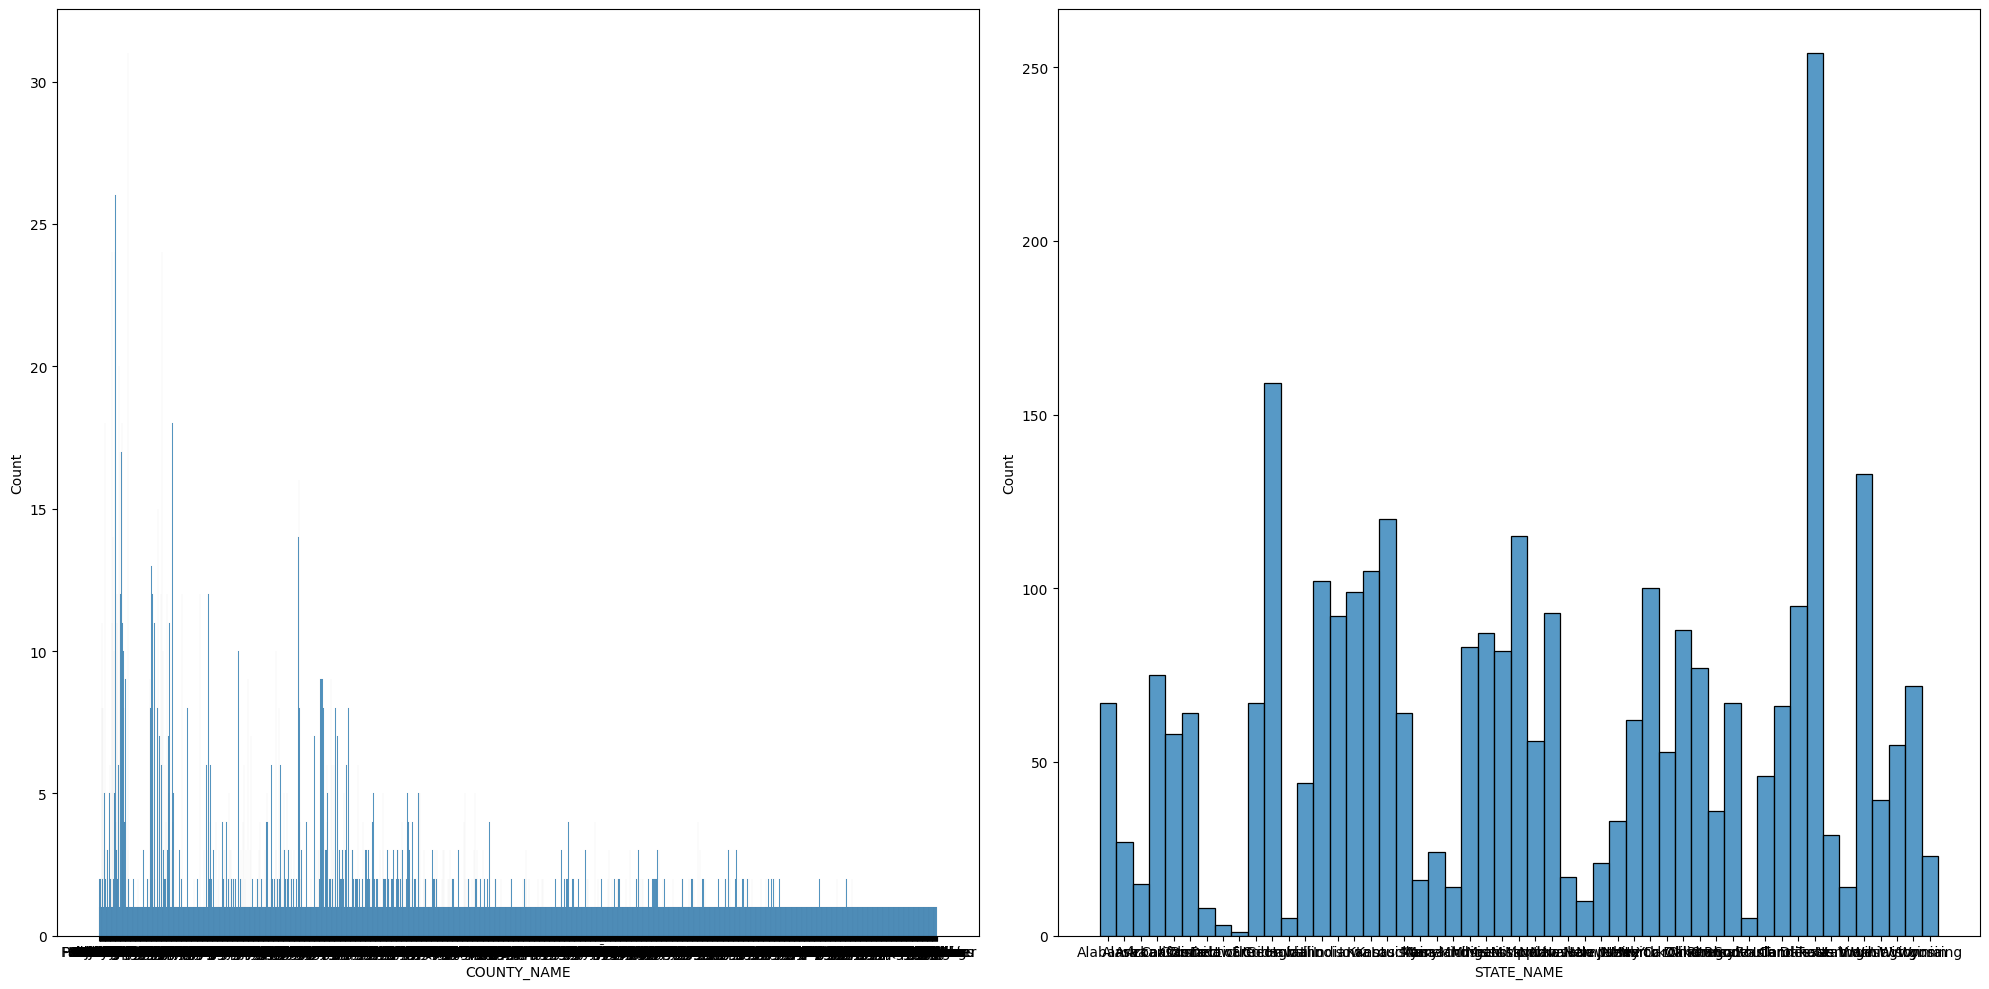

In [13]:
# HISTOGRA MÚLTIPLE
fig, axis = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(data=total_data, x='COUNTY_NAME', ax=axis[0])
sns.histplot(data=total_data, x='STATE_NAME', ax=axis[1])

plt.tight_layout()
plt.show()

**2. LIMPIEZA INICIAL**

In [14]:
total_data.duplicated().sum()

np.int64(0)

In [15]:
total_data[total_data.duplicated() == True]

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code


In [16]:
total_data.value_counts()

fips   TOT_POP  0-9    0-9 y/o % of total pop  19-Oct  10-19 y/o % of total pop  20-29  20-29 y/o % of total pop  30-39  30-39 y/o % of total pop  40-49  40-49 y/o % of total pop  50-59  50-59 y/o % of total pop  60-69  60-69 y/o % of total pop  70-79  70-79 y/o % of total pop  80+   80+ y/o % of total pop  White-alone pop  % White-alone  Black-alone pop  % Black-alone  Native American/American Indian-alone pop  % NA/AI-alone  Asian-alone pop  % Asian-alone  Hawaiian/Pacific Islander-alone pop  % Hawaiian/PI-alone  Two or more races pop  % Two or more races  POP_ESTIMATE_2018  N_POP_CHG_2018  GQ_ESTIMATES_2018  R_birth_2018  R_death_2018  R_NATURAL_INC_2018  R_INTERNATIONAL_MIG_2018  R_DOMESTIC_MIG_2018  R_NET_MIG_2018  Less than a high school diploma 2014-18  High school diploma only 2014-18  Some college or associate's degree 2014-18  Bachelor's degree or higher 2014-18  Percent of adults with less than a high school diploma 2014-18  Percent of adults with a high school diploma only 

In [17]:
total_data = total_data.drop_duplicates(keep="first")
print(total_data.shape)
total_data.head()

(3140, 108)


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [18]:
# ELIMINO LAS COLUMNAS QUE DECIDÍ ELIMINAR
total_data.drop(columns=['COUNTY_NAME','STATE_NAME'], inplace=True)
total_data = total_data.dropna().reset_index(drop=True)
total_data.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


- Se eliminaron las variables 'COUNTY_NAME' y 'STATE_NAME' porque no aportan valor predictivo al modelo. Además, al ser las únicas variables categóricas, no se pueden utilizar directamente en una regresión lineal sin que se transformen previamente.

In [19]:
# OTRAS COLUMNAS QUE DECIDÍ ELIMINAR
total_data.drop(columns=['anycondition_Lower 95% CI','anycondition_Upper 95% CI', 'anycondition_number', 'fips', 'STATE_FIPS', 'CNTY_FIPS'], inplace=True)
total_data = total_data.dropna().reset_index(drop=True)
total_data.head()

,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,3038,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,7474,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [20]:
total_data.shape

(3140, 100)

In [21]:
total_data.isna().sum()

TOT_POP                     0
0-9                         0
0-9 y/o % of total pop      0
19-Oct                      0
10-19 y/o % of total pop    0
                           ..
CKD_prevalence              0
CKD_Lower 95% CI            0
CKD_Upper 95% CI            0
CKD_number                  0
Urban_rural_code            0
Length: 100, dtype: int64

In [22]:
total_data.columns

Index(['TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct',
       '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop',
       '30-39', '30-39 y/o % of total pop', '40-49',
       '40-49 y/o % of total pop', '50-59', '50-59 y/o % of total pop',
       '60-69', '60-69 y/o % of total pop', '70-79',
       '70-79 y/o % of total pop', '80+', '80+ y/o % of total pop',
       'White-alone pop', '% White-alone', 'Black-alone pop', '% Black-alone',
       'Native American/American Indian-alone pop', '% NA/AI-alone',
       'Asian-alone pop', '% Asian-alone',
       'Hawaiian/Pacific Islander-alone pop', '% Hawaiian/PI-alone',
       'Two or more races pop', '% Two or more races', 'POP_ESTIMATE_2018',
       'N_POP_CHG_2018', 'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018',
       'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018',
       'R_NET_MIG_2018', 'Less than a high school diploma 2014-18',
       'High school diploma only 2014-18',
       'Some col

**3. ANÁLISIS DE VARIABLES**

- Se eliminaron las variables 'COUNTY_NAME' y 'STATE_NAME' porque no aportan valor predictivo al modelo. Además, al ser las únicas variables categóricas, no se pueden utilizar directamente en una regresión lineal sin transformarlas previamente.
- Se eliminaron las variables 'anycondition_Lower 95% CI','anycondition_Upper 95% CI' y 'anycondition_number' porque son derivados directos de la variable objetivo y dejarlas podría causar data leakage.
- Se eliminaron las variables 'fips', 'STATE_FIPS', 'CNTY_FIPS' porque son identificadores; no aportan valor.
- Debido al alto número de variables numéricas (100), se seleccionaron aquellas con mayor correlación con la variable objetivo para facilitar la interpretación.
- Se seleccionó 'anycondition_prevalence' como variable objetivo, ya que representa el porcentaje de población con alguna condición médica, siendo un indicador global del estado de salud. Esto permite analizar cómo los factores sociodemográficos y los recursos sanitarios influyen en la salud de la población.

In [23]:
target = 'anycondition_prevalence'

In [24]:
# Correlación con la variable objetivo
corr = total_data.corr()
corr_target = corr[target].sort_values(ascending=False)
corr_target

anycondition_prevalence                                         1.000000
Obesity_prevalence                                              0.894438
Obesity_Upper 95% CI                                            0.894357
Obesity_Lower 95% CI                                            0.891411
diabetes_Upper 95% CI                                           0.852373
                                                                  ...   
CI90UBINC_2018                                                 -0.698453
MEDHHINC_2018                                                  -0.706113
Median_Household_Income_2018                                   -0.706113
CI90LBINC_2018                                                 -0.708710
Percent of adults with a bachelor's degree or higher 2014-18   -0.768119
Name: anycondition_prevalence, Length: 100, dtype: float64

In [25]:
top_features = corr_target[1:11].index  # Quito el target
top_features

Index(['Obesity_prevalence', 'Obesity_Upper 95% CI', 'Obesity_Lower 95% CI',
       'diabetes_Upper 95% CI', 'diabetes_prevalence', 'diabetes_Lower 95% CI',
       'COPD_Lower 95% CI', 'COPD_prevalence', 'Heart disease_Lower 95% CI',
       'COPD_Upper 95% CI'],
      dtype='str')

<Axes: xlabel='anycondition_prevalence', ylabel='Count'>

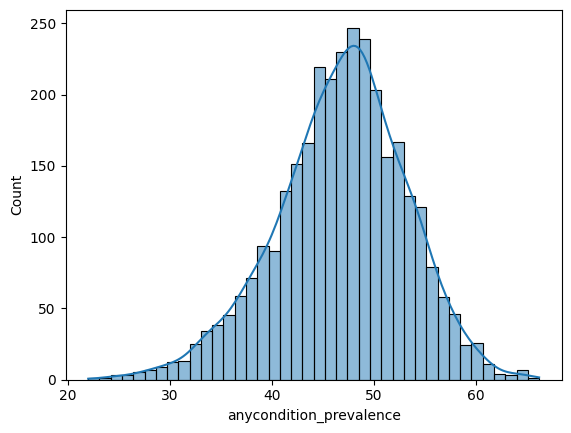

In [26]:
sns.histplot(total_data[target], kde=True)

**4. RELACIÓN CON VARIABLES IMPORTANTES**

<function matplotlib.pyplot.show(close=None, block=None)>

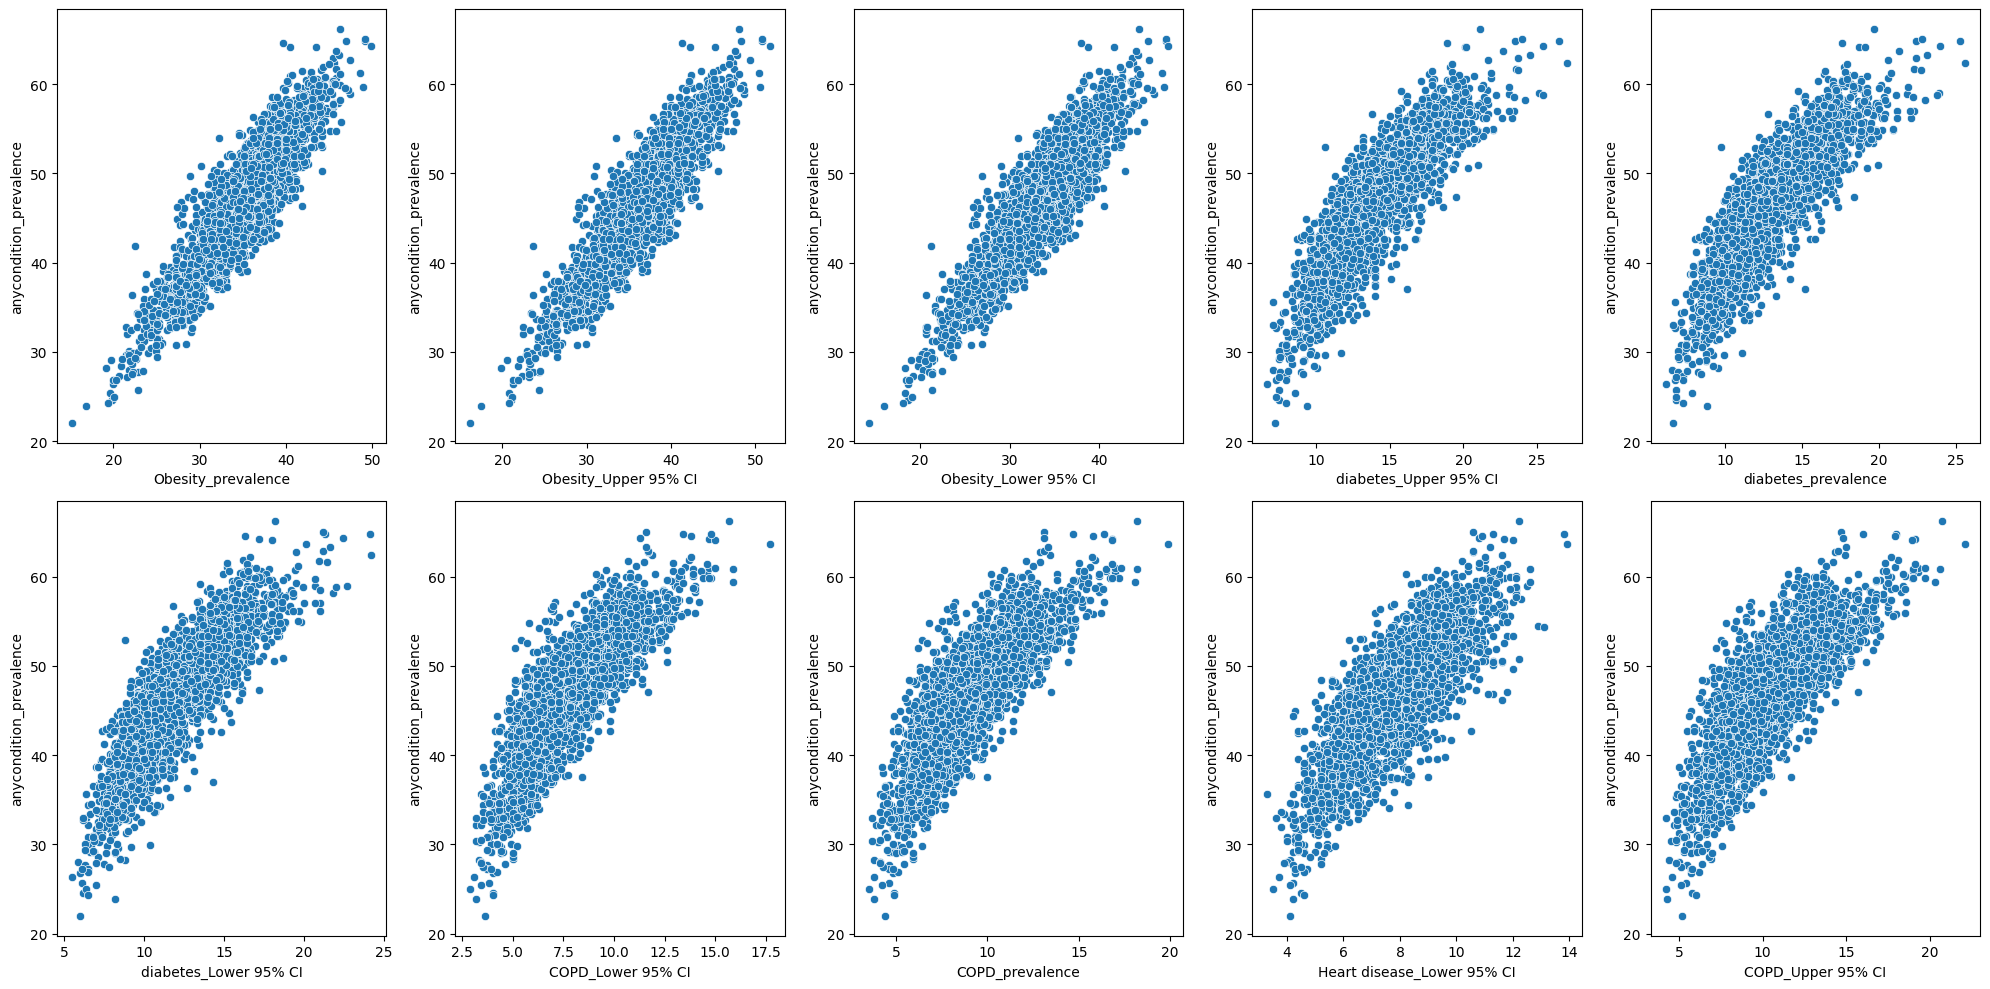

In [27]:
fig, axis = plt.subplots(2, 5, figsize=(20, 10))
axis = axis.flatten()
for i, col in enumerate(top_features):
    sns.scatterplot(data=total_data, x=col, y=target, ax=axis[i])
plt.tight_layout()
plt.show

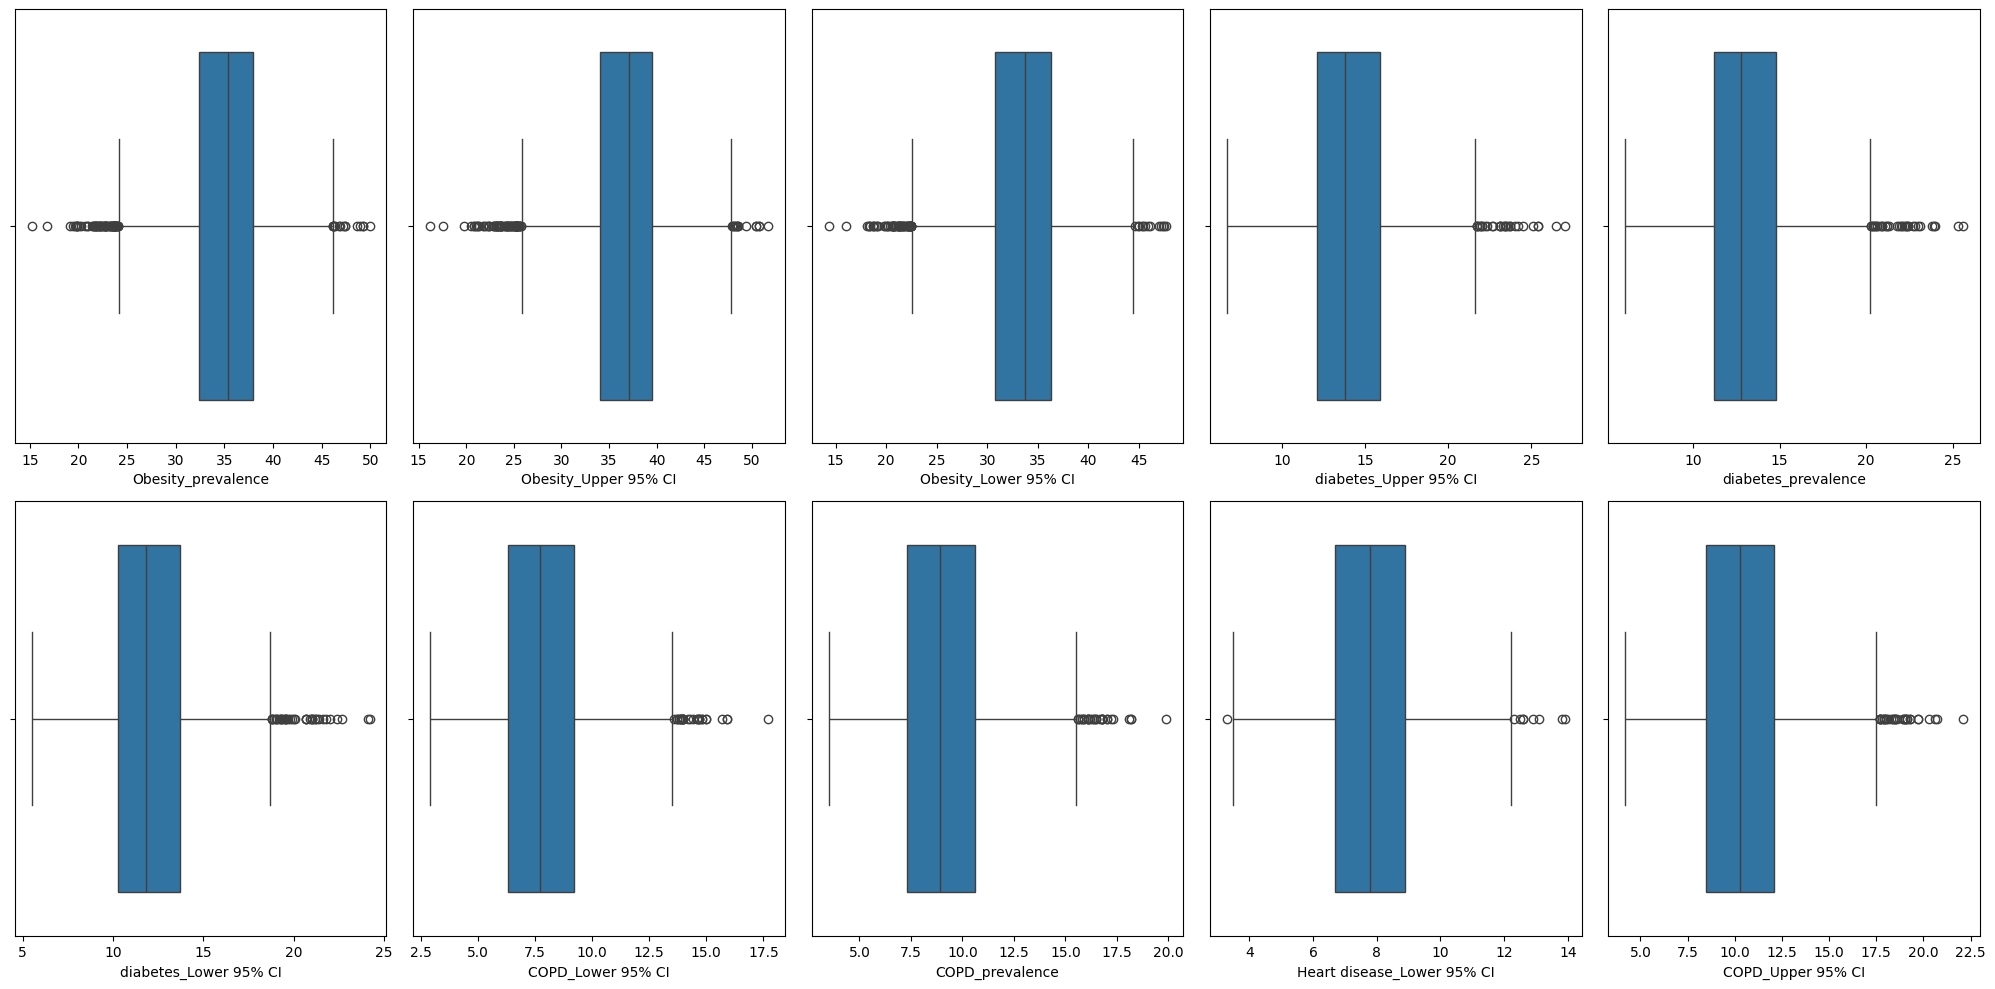

In [28]:
fig, axis = plt.subplots(2, 5, figsize=(20, 10))

sns.boxplot(ax = axis[0, 0], x = total_data["Obesity_prevalence"])
sns.boxplot(ax = axis[0, 1], x = total_data["Obesity_Upper 95% CI"])
sns.boxplot(ax = axis[0, 2], x = total_data["Obesity_Lower 95% CI"])
sns.boxplot(ax = axis[0, 3], x = total_data["diabetes_Upper 95% CI"])
sns.boxplot(ax = axis[0, 4], x = total_data["diabetes_prevalence"])

sns.boxplot(ax = axis[1, 0], x = total_data["diabetes_Lower 95% CI"])
sns.boxplot(ax = axis[1, 1], x = total_data["COPD_Lower 95% CI"])
sns.boxplot(ax = axis[1, 2], x = total_data["COPD_prevalence"])
sns.boxplot(ax = axis[1, 3], x = total_data["Heart disease_Lower 95% CI"])
sns.boxplot(ax = axis[1, 4], x = total_data["COPD_Upper 95% CI"])

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

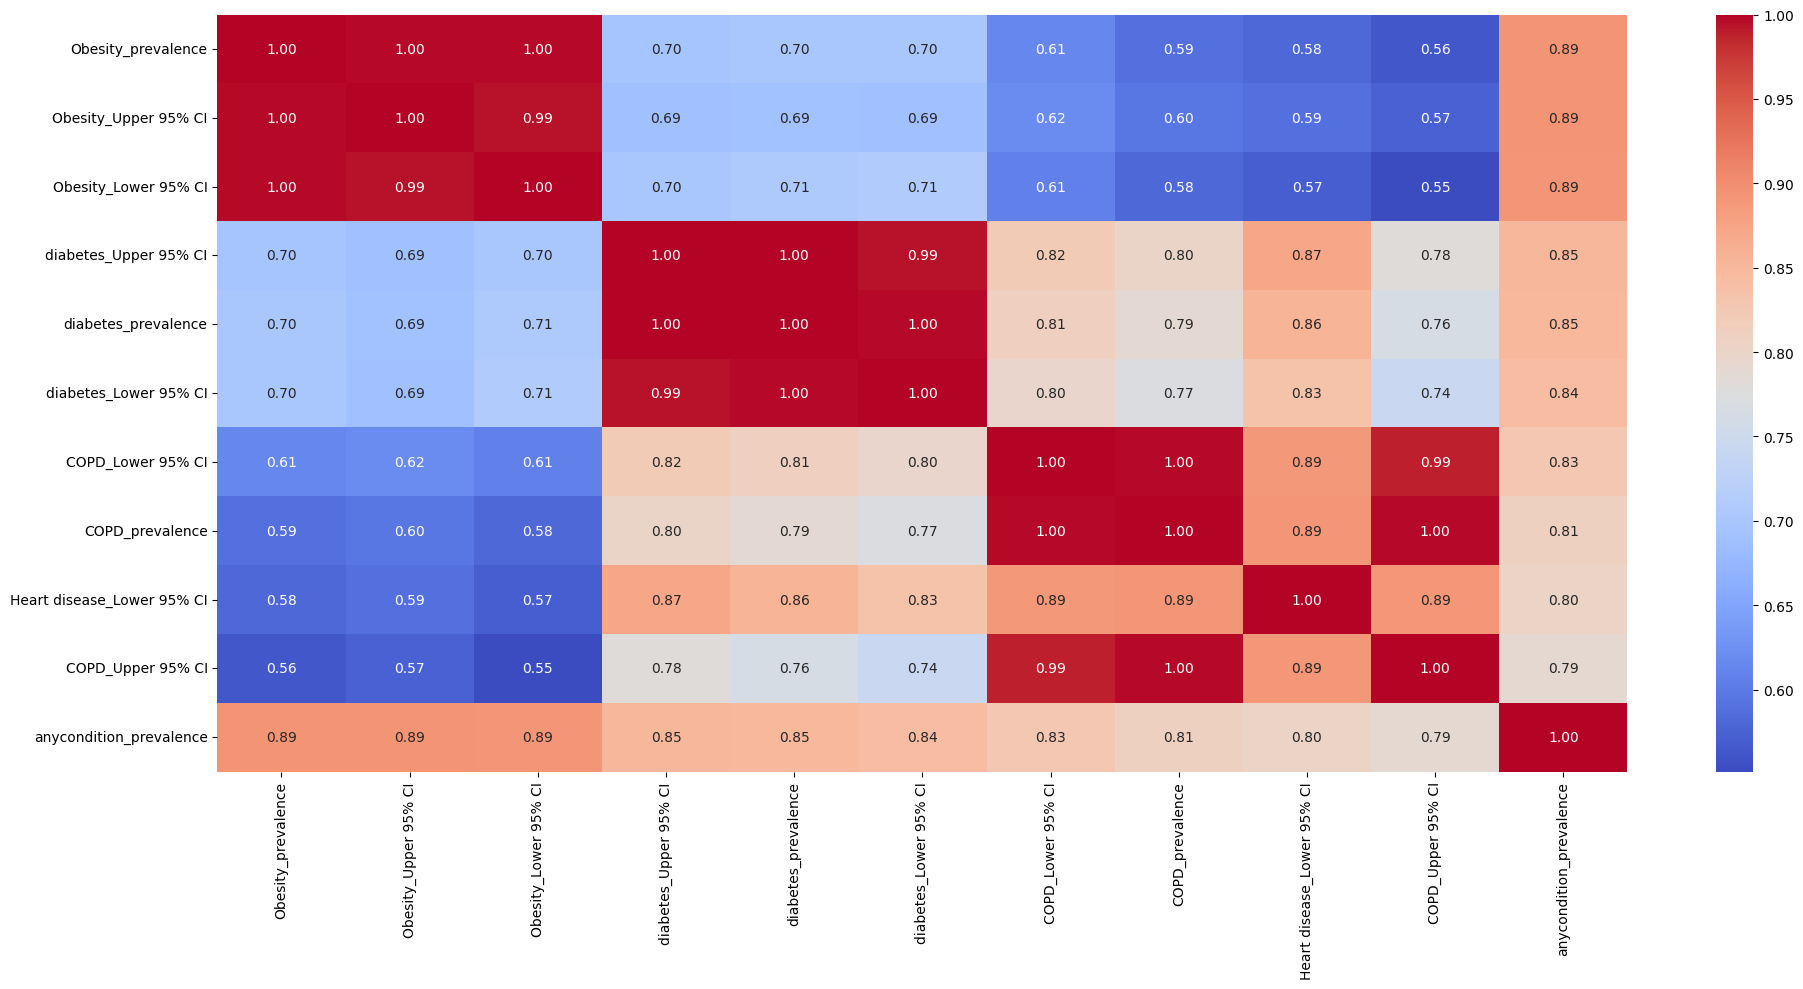

In [29]:
# Heatmap SOLO con variables relevantes
selected = list(top_features) + [target]

fig, ax= plt.subplots(figsize=(20, 10))
sns.heatmap(total_data[selected].corr(method="pearson"),
            annot=True, fmt=".2f", cmap="coolwarm", ax=ax)

plt.tight_layout()
plt.show

**5. INGENIERÍA DE CARACTERÍSTICAS**

In [30]:
total_data.describe()

,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
count,3.140000e+03,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,...,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000
mean,1.041894e+05,1.274030e+04,11.871051,1.336798e+04,12.694609,1.446933e+04,12.283979,1.391649e+04,11.751535,1.288521e+04,...,5827.242357,13.073503,12.088089,14.053726,9326.577707,3.446242,3.207516,3.710478,2466.234076,4.635350
std,3.335834e+05,4.180730e+04,2.124081,4.228439e+04,1.815044,4.957773e+04,3.126297,4.899095e+04,1.696599,4.347219e+04,...,15720.551934,2.724351,2.622948,2.824828,29754.601185,0.568059,0.527740,0.613069,7730.422067,1.510447
min,8.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.100000e+01,6.092789,4.000000e+00,...,7.000000,6.100000,5.500000,6.700000,11.000000,1.800000,1.700000,1.900000,3.000000,1.000000
25%,1.096325e+04,1.280500e+03,10.594639,1.374500e+03,11.674504,1.263750e+03,10.496774,1.232750e+03,10.689322,1.245250e+03,...,815.000000,11.200000,10.300000,12.100000,1187.750000,3.100000,2.900000,3.300000,314.750000,3.000000
50%,2.580050e+04,3.057000e+03,11.802727,3.274000e+03,12.687422,3.108000e+03,11.772649,3.000500e+03,11.580861,3.048500e+03,...,1963.500000,12.800000,11.800000,13.800000,2743.000000,3.400000,3.200000,3.700000,718.000000,5.000000
75%,6.791300e+04,8.097000e+03,12.951840,8.822250e+03,13.659282,8.976250e+03,13.182260,8.314250e+03,12.639379,8.120500e+03,...,4727.000000,14.800000,13.700000,15.900000,6679.250000,3.800000,3.500000,4.100000,1776.250000,6.000000
max,1.010552e+07,1.208253e+06,25.460677,1.239139e+06,23.304372,1.557073e+06,37.570198,1.501844e+06,22.225129,1.350076e+06,...,434075.000000,25.600000,24.200000,27.000000,952335.000000,6.200000,5.800000,6.600000,237766.000000,6.000000


**Outliers para la variable objetivo ('anycondition_prevalence')**

In [31]:
# STATS TARGET
target_stats = total_data["anycondition_prevalence"].describe()
target_stats

count    3140.000000
mean       46.793917
std         6.379448
min        22.000000
25%        42.900000
50%        47.200000
75%        51.000000
max        66.200000
Name: anycondition_prevalence, dtype: float64

In [32]:
# IQR TARGET
# RANGO INTERCUARTIL
target_iqr = target_stats["75%"] - target_stats["25%"]
# LÍMITE SUPERIOR == Q3 + 1.5*IQR
upper_limit = target_stats["75%"] + 1.5 * target_iqr
# LÍMITE INFERIOR == Q1 + 1.5*IQR
lower_limit = target_stats["25%"] - 1.5 * target_iqr

print(f"IQR: {target_iqr}")
print(f"Upper limit: {upper_limit}")
print(f"Lower limit: {lower_limit}")

IQR: 8.100000000000001
Upper limit: 63.150000000000006
Lower limit: 30.749999999999996


In [33]:
total_data[total_data.anycondition_prevalence > 22]

,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,3038,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,7474,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,43051,6104,14.178532,6326,14.694200,5359,12.448027,6577,15.277229,5334,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,23081,2384,10.328842,2185,9.466661,2967,12.854729,4093,17.733200,3423,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,20299,3121,15.375142,3205,15.788955,2153,10.606434,2702,13.311001,2390,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,7885,858,10.881420,1113,14.115409,715,9.067850,903,11.452124,900,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6


**6. TRAIN / TEST SPLIT**

In [34]:
# SEPARO X E Y
mi_x = total_data.drop(target, axis=1)
mi_y = total_data[target]

In [35]:
# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(mi_x, mi_y, test_size=0.2, random_state=42)

In [39]:
# LINEAR REGRESSION
model = LinearRegression()

In [40]:
# ENTRENO EL MODELO
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
model.intercept_

np.float64(21.341357731806117)

In [42]:
model.coef_

array([ 2.82898425e-05, -6.65501967e-05, -1.18483954e-01, -8.00154906e-06,
       -1.54974043e-02,  5.69495300e-05, -2.66024090e-02,  2.92246681e-05,
        5.78723990e-02,  7.09916510e-05,  4.13033923e-02,  4.44138233e-05,
       -6.48270990e-02, -2.36722563e-05, -1.05749070e-01, -5.16571092e-06,
        1.27308047e-01, -6.99000949e-05,  1.04676104e-01, -8.11124453e-07,
       -2.87060797e-02, -3.29234106e-06, -1.42677488e-02,  1.77300727e-05,
       -2.52971189e-02,  2.19734493e-06, -7.45543213e-02,  4.15065833e-05,
        8.47910091e-02, -2.90405938e-05,  5.80342676e-02,  2.82898574e-05,
        2.33105416e-05,  2.71925966e-05,  6.58868074e-01, -5.26566352e-01,
       -5.97881547e-01,  3.17251904e-03,  5.31061731e-02, -5.45410128e-02,
        3.61796851e-05,  1.64366764e-05,  4.73335313e-05,  3.52514393e-05,
       -6.25711770e-02, -8.75512367e-02, -4.03248185e-02, -1.16046668e-01,
        8.76189534e-06, -8.32304020e-03,  3.61024627e-02, -2.42182893e-02,
       -4.61990272e-06, -

In [46]:
# PREDICCIONES
y_pred = model.predict(X_test)

In [45]:
# MSE
mean_squared_error(y_test, y_pred)

2.1931054273971684

- El Error Cuadrático Medio (MSE) de 2.19 indica que, en promedio, las predicciones se desvían del valor real alrededor de 1.47 unidades.

In [47]:
# R²
r2_score(y_test, y_pred)

0.9460549855236156

- El modelo explica aproximadamente el 94% de la variabilidad.

In [57]:
# MODELO LASSO
lasso_model = Lasso(alpha=0.1, max_iter=300, random_state=42)

# ENTRENO EL MODELO
lasso_model.fit(X_train, y_train)

# PREDICCIONES
y_pred_lasso = lasso_model.predict(X_test)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.374e+03, tolerance: 1.022e+01
  model = cd_fast.enet_coordinate_descent(


In [60]:
# Probar distintos alpha
alphas = np.linspace(0, 20, 50)
scores = []

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(r2_score(y_test, y_pred))

/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.542e+03, tolerance: 1.022e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_co

Text(0.5, 1.0, 'Lasso performance')

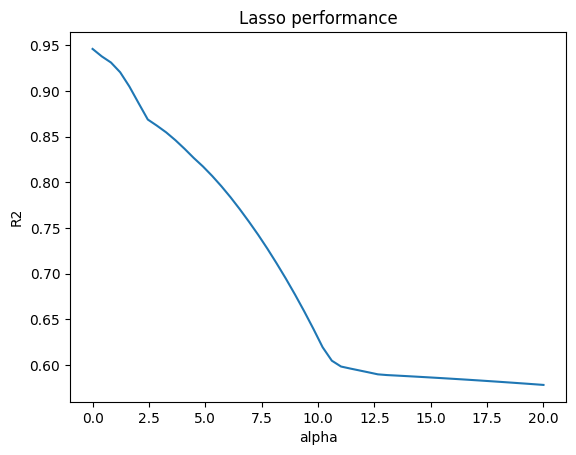

In [62]:
# GRAFICAR RESULTADOS
plt.plot(alphas, scores)
plt.xlabel("alpha")
plt.ylabel("R2")
plt.title("Lasso performance")

**7. OPTIMIZACIÓN DEL MODELO**

In [58]:
# MODELO RIDGE
ridge_model = Ridge(alpha=0.1, max_iter=300, random_state=42)

# ENTRENO EL MODELO RIDGE
ridge_model.fit(X_train, y_train)

# PREDICCIONES
y_pred_ridge = ridge_model.predict(X_test)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0483196518631398e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


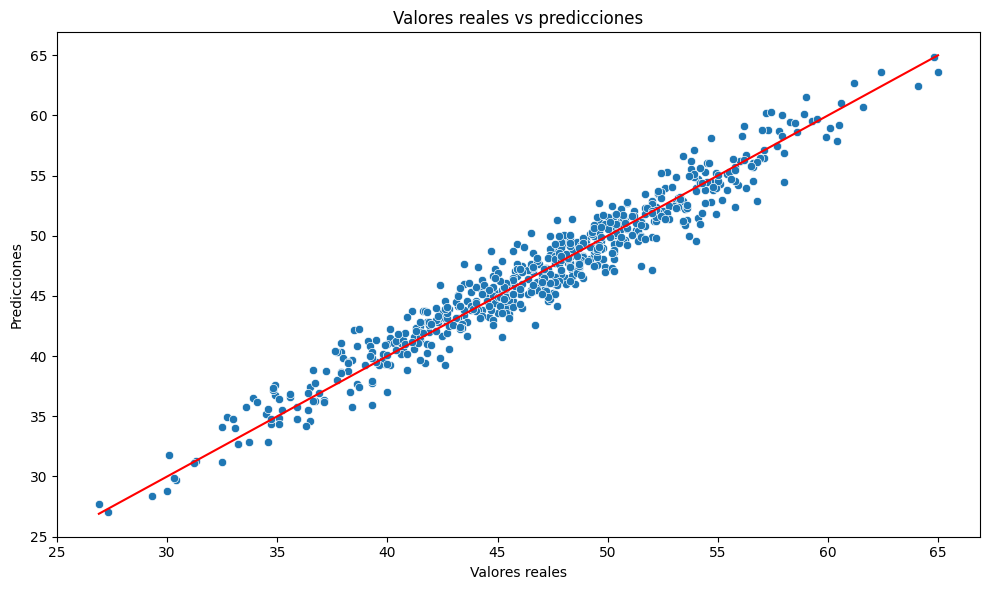

In [59]:
# GRÁFICO VALORES REALES VS VALORES PREDICHOS
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(x=y_test, y=y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs predicciones")
plt.tight_layout()
plt.show()

**8. CONCLUSIONES**

- El dataset inicial contenía 3140 filas y 108 columnas relacionadas con datos sociodemográficos a nivel de condado de EE. UU. (2018-2019).
- Incluye variables relacionnadas con la salud de las personas.
- El objetivo es descubrir si existe alguna relación entre los recursos de salud y los datos sociodemográficos.

**Análisis de variables**
- Se eliminaron las variables 'COUNTY_NAME' y 'STATE_NAME' porque no aportan valor predictivo al modelo. Además, al ser las únicas variables categóricas, no se pueden utilizar directamente en una regresión lineal sin transformarlas previamente.
- Se eliminaron las variables 'anycondition_Lower 95% CI','anycondition_Upper 95% CI' y 'anycondition_number' porque son derivados directos de la variable objetivo y dejarlas podría causar data leakage.
- Se eliminaron las variables 'fips', 'STATE_FIPS', 'CNTY_FIPS' porque son identificadores; no aportan valor.
- Debido al alto número de variables numéricas (100), se seleccionaron aquellas con mayor correlación con la variable objetivo para facilitar la interpretación.
- Se seleccionó 'anycondition_prevalence' como variable objetivo, ya que representa el porcentaje de población con alguna condición médica, siendo un indicador global del estado de salud. Esto permite analizar cómo los factores sociodemográficos y los recursos sanitarios influyen en la salud de la población.

**Matriz de correlación**


**Conclusiones del proyecto**
- El modelo explica aproximadamente el 94% de la variabilidad.
- El Error Cuadrático Medio (MSE) de 2.19 indica que, en promedio, las predicciones se desvían del valor real alrededor de 1.47 unidades.